In [37]:
import numpy as np
import pandas as pd

In [38]:
year_datas = []
for year in range(1997, 2007):
    yearly_data = pd.read_csv(f'./Plane Data/{year}.csv', encoding='latin-1', dtype={"CancellationCode": object})
    yearly_data = yearly_data[yearly_data['DepDelay'] > 0]
    yearly_data = yearly_data[yearly_data['ArrDelay'] > 0]
    yearly_data["TotalDelay"] = yearly_data['DepDelay'] + yearly_data['ArrDelay']
    yearly_data = yearly_data[['Year', 'TailNum', 'TotalDelay']]
    year_datas.append(yearly_data)

plane_data = pd.read_csv('./Plane Data/plane-data.csv', encoding='latin-1')
plane_data = plane_data[['tailnum', 'issue_date', 'year']]

In [39]:
plane_data.rename(columns={'tailnum': 'TailNum'}, inplace=True)
plane_data['issue_date'] = pd.to_datetime(plane_data['issue_date'])
plane_data['issue_year'] = plane_data['issue_date'].dt.year
plane_data['plane_year'] = plane_data['year'].fillna(plane_data['issue_year'])

plane_data['plane_year'] = np.where(plane_data['plane_year'] == 0, plane_data['issue_year'], plane_data['plane_year'])

plane_data

,TailNum,issue_date,year,issue_year,plane_year
0,N050AA,NaT,NaN,NaN,NaN
1,N051AA,NaT,NaN,NaN,NaN
2,N052AA,NaT,NaN,NaN,NaN
3,N054AA,NaT,NaN,NaN,NaN
4,N055AA,NaT,NaN,NaN,NaN
...,...,...,...,...,...
5024,N997DL,1992-03-11,1992.0,1992.0,1992.0
5025,N998AT,2003-01-23,2002.0,2003.0,2002.0
5026,N998DL,1992-04-02,1992.0,1992.0,1992.0
5027,N999CA,2008-07-09,1998.0,2008.0,1998.0


In [40]:
year_datas[0]

,Year,TailNum,TotalDelay
1,1997,N626,19.0
2,1997,N321,16.0
3,1997,N383,17.0
4,1997,N513,82.0
7,1997,N694,24.0
...,...,...,...
5411814,1997,N448AA,19.0
5411820,1997,N410AA,103.0
5411823,1997,N431AA,204.0
5411825,1997,N549AA,96.0


In [41]:
for i, year_data in enumerate(year_datas):
    year_data = year_data.merge(plane_data, on='TailNum', how='left')
    year_data = year_data[year_data['plane_year'].notna()]
    year_data['plane_year'] = year_data['plane_year'].astype(int)
    year_data['Year'] = year_data['Year'].astype(int)
    year_data['plane_age'] = year_data['Year'] - year_data['plane_year']
    year_data = year_data[year_data['plane_age'] >= 0]
    year_datas[i] = year_data


Year 1997
    plane_age  TotalDelay
0           0   52.952293
1           1   52.727842
2           2   48.438439
3           3   50.289114
4           4   47.547646
5           5   49.282155
6           6   49.393793
7           7   49.369670
8           8   51.062413
9           9   50.076542
10         10   52.217253
11         11   57.749087
12         12   56.953742
13         13   53.447196
14         14   64.129353
15         15   72.306507
16         17   65.338223
17         18   66.015636
18         19   63.663486
19         20   65.925580
20         21   68.177102
21         22   63.325791
22         23   62.633333
23         24   62.170971
24         25   60.901961
25         26   63.772727
26         27   61.745595
27         28   62.735376
28         29   63.153331
29         30   66.992200
30         32   33.332506
31         33   50.026471
32         34   61.733516
33         35   62.457237
34         38   74.702595
35         41   90.000000
Year 1998
    plane_age  Tot

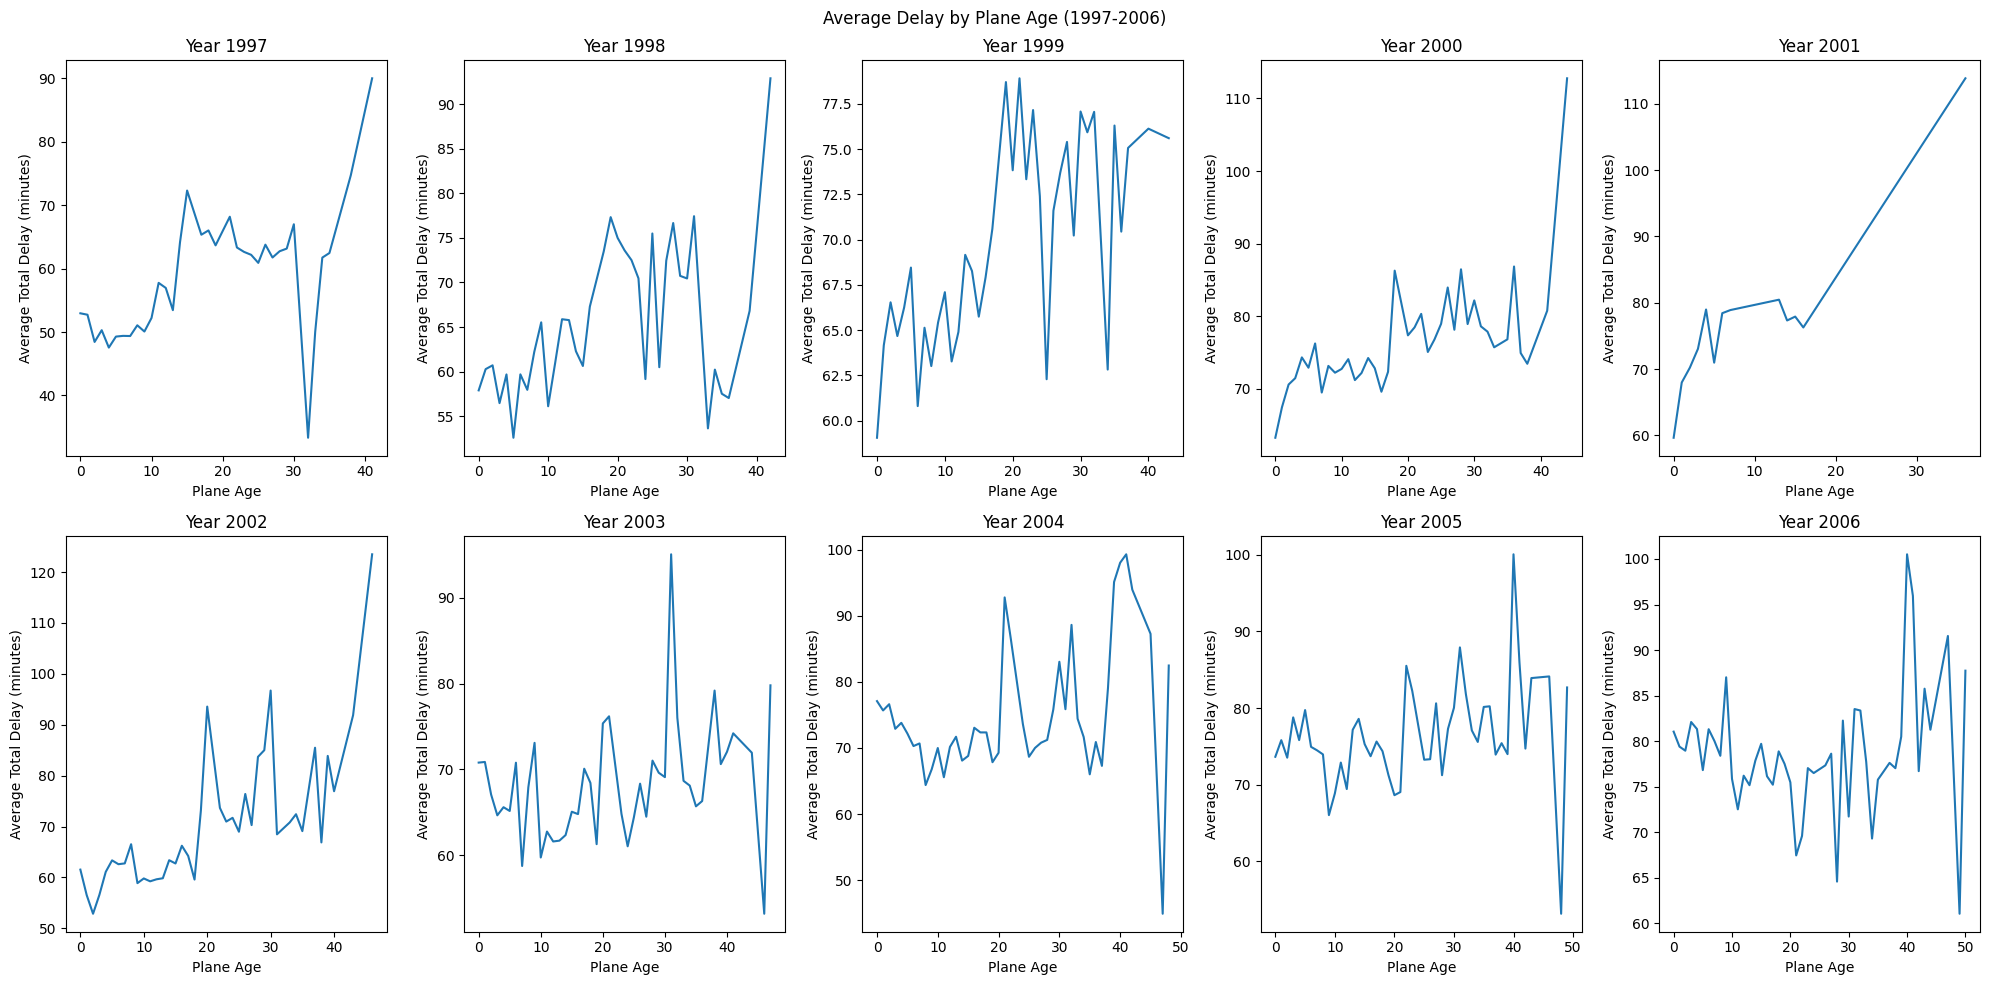

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Average Delay by Plane Age (1997-2006)')

for i, year_data in enumerate(year_datas):
    plane_age_group = year_data.groupby('plane_age')
    plane_age_group = plane_age_group['TotalDelay'].mean()
    plane_age_group = plane_age_group.reset_index()
    
    print(f'Year {1997 + i}')
    print(plane_age_group)    

    sns.lineplot(data=plane_age_group, x='plane_age', y='TotalDelay', ax=ax[i//5, i%5])
    ax[i//5, i%5].set_title(f'Year {1997 + i}')
    ax[i//5, i%5].set_xlabel('Plane Age')
    ax[i//5, i%5].set_ylabel('Average Total Delay (minutes)')

plt.tight_layout()
plt.show()
    
    